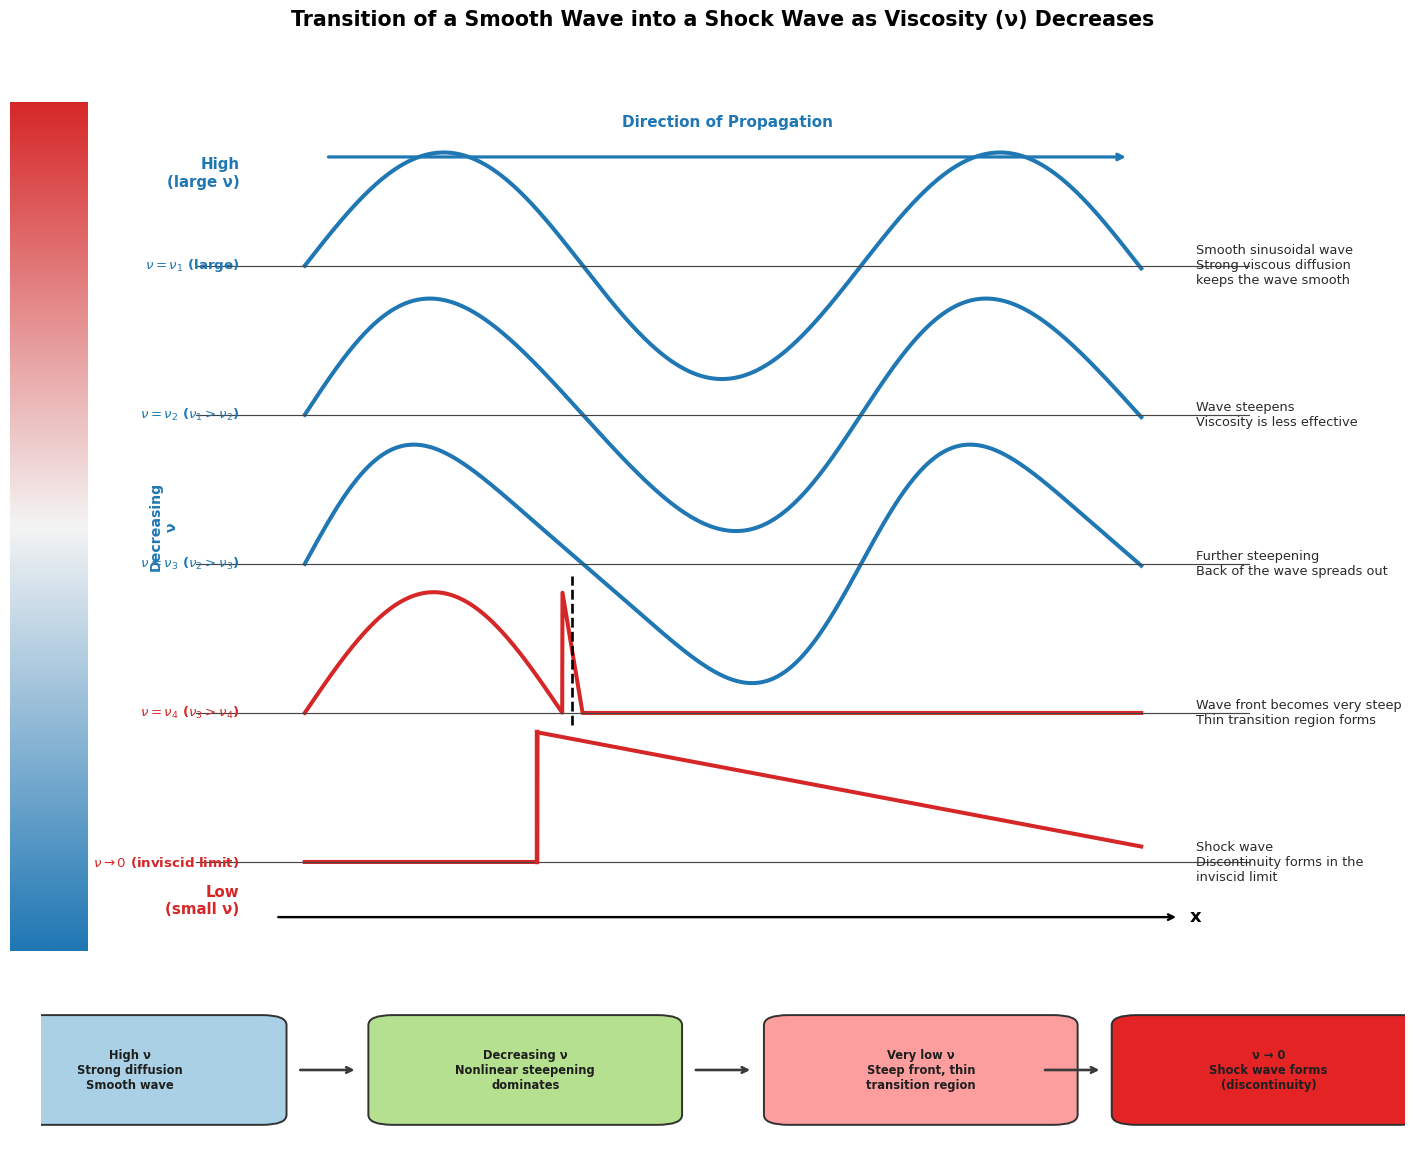

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap

fig = plt.figure(figsize=(15.5, 11.8))

# ==================== MAIN FIGURE ====================
ax = fig.add_axes([0.16, 0.18, 0.68, 0.72])

x = np.linspace(0, 10, 3000)

# Wave shapes exactly as in your figure
y1 = 0.76 * np.sin(2 * np.pi * x / 6.65)                          # High ν - smooth sinusoidal
y2 = 0.78 * np.sin(2 * np.pi * x / 6.65 + 0.16 * np.sin(2 * np.pi * x / 6.65))
y3 = 0.80 * np.sin(2 * np.pi * x / 6.65 + 0.36 * np.sin(2 * np.pi * x / 6.65))

# Row 4 - very steep front + thin transition region
y4 = np.zeros_like(x)
y4[x < 3.08] = 0.81 * np.sin(np.pi * x[x < 3.08] / 3.08)
y4[(x >= 3.08) & (x < 3.32)] = 0.81 * (3.32 - x[(x >= 3.08) & (x < 3.32)]) / 0.24
y4[x >= 3.32] = 0.0

# Row 5 - inviscid shock (discontinuity + linear decay)
y5 = np.zeros_like(x)
y5[x >= 2.78] = 0.87 * np.maximum(0, 1 - 0.122 * (x[x >= 2.78] - 2.78))

offsets = [4.05, 3.05, 2.05, 1.05, 0.05]
wave_colors = ['#1f77b4', '#1f77b4', '#1f77b4', '#d62728', '#d62728']

ax.plot(x, y1 + offsets[0], color=wave_colors[0], lw=2.9)
ax.plot(x, y2 + offsets[1], color=wave_colors[1], lw=2.9)
ax.plot(x, y3 + offsets[2], color=wave_colors[2], lw=2.9)
ax.plot(x, y4 + offsets[3], color=wave_colors[3], lw=2.9)
ax.plot(x, y5 + offsets[4], color=wave_colors[4], lw=2.9)

for off in offsets:
    ax.axhline(off, color='#444444', lw=0.85)

# Dashed line (thin transition region)
ax.plot([3.20, 3.20], [offsets[3]-0.08, offsets[3]+0.92], 'k--', lw=1.9)

# Shock discontinuity
ax.plot([2.78, 2.78], [offsets[4], offsets[4]+0.87], color='#d62728', lw=3.2)

ax.set_xlim(-1.3, 11.3)
ax.set_ylim(-0.55, 5.15)
ax.axis('off')

# Direction arrow
ax.annotate('', xy=(9.85, 4.78), xytext=(0.25, 4.78),
            arrowprops=dict(arrowstyle='->', color='#1f77b4', lw=2.3))
ax.text(5.05, 4.98, 'Direction of Propagation', ha='center', fontsize=11,
        color='#1f77b4', fontweight='bold')

# x arrow
ax.annotate('', xy=(10.45, -0.32), xytext=(-0.35, -0.32),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.7))
ax.text(10.58, -0.32, 'x', fontsize=13, fontweight='bold', va='center')

# ==================== LEFT LABELS ====================
left_labels = [
    (4.05, r'$\nu = \nu_1$ (large)', '#1f77b4'),
    (3.05, r'$\nu = \nu_2$ ($\nu_1 > \nu_2$)', '#1f77b4'),
    (2.05, r'$\nu = \nu_3$ ($\nu_2 > \nu_3$)', '#1f77b4'),
    (1.05, r'$\nu = \nu_4$ ($\nu_3 > \nu_4$)', '#d62728'),
    (0.05, r'$\nu \to 0$ (inviscid limit)', '#d62728'),
]
for y, txt, col in left_labels:
    ax.text(-0.78, y, txt, ha='right', va='center', fontsize=9.6, color=col, fontweight='bold')

ax.text(-0.78, 4.78, 'High\n(large ν)', ha='right', va='top', fontsize=10.8,
        color='#1f77b4', fontweight='bold')
ax.text(-0.78, -0.32, 'Low\n(small ν)', ha='right', va='bottom', fontsize=10.8,
        color='#d62728', fontweight='bold')

ax.annotate('', xy=(-1.38, 0.22), xytext=(-1.38, 4.38),
            arrowprops=dict(arrowstyle='->', color='#1f77b4', lw=2.6))
ax.text(-1.68, 2.3, 'Decreasing\nν', ha='center', va='center', fontsize=10.2,
        color='#1f77b4', rotation=90, fontweight='bold')

# ==================== RIGHT CAPTIONS (from your text) ====================
right_captions = [
    (4.05, 'Smooth sinusoidal wave\nStrong viscous diffusion\nkeeps the wave smooth'),
    (3.05, 'Wave steepens\nViscosity is less effective'),
    (2.05, 'Further steepening\nBack of the wave spreads out'),
    (1.05, 'Wave front becomes very steep\nThin transition region forms'),
    (0.05, 'Shock wave\nDiscontinuity forms in the\ninviscid limit'),
]
for y, txt in right_captions:
    ax.text(10.65, y, txt, ha='left', va='center', fontsize=9.3, color='#2a2a2a')

# ==================== GRADIENT BAR ====================
grad_ax = fig.add_axes([0.04, 0.18, 0.05, 0.72])
grad = np.linspace(1, 0, 320).reshape(-1, 1)
cmap = LinearSegmentedColormap.from_list("visc", ["#1f77b4", "#f4f4f4", "#d62728"], N=320)
grad_ax.imshow(grad, aspect='auto', cmap=cmap, extent=[0, 1, 0, 5])
grad_ax.axis('off')

# ==================== BOTTOM FLOW CHART ====================
bot = fig.add_axes([0.06, 0.01, 0.88, 0.155])
bot.set_xlim(0, 10)
bot.set_ylim(0, 3.3)
bot.axis('off')

boxes = [
    (0.65, 'High ν\nStrong diffusion\nSmooth wave', '#a6cee3'),
    (3.55, 'Decreasing ν\nNonlinear steepening\ndominates', '#b2df8a'),
    (6.45, 'Very low ν\nSteep front, thin\ntransition region', '#fb9a99'),
    (9.0, 'ν → 0\nShock wave forms\n(discontinuity)', '#e31a1c'),
]
for xp, txt, col in boxes:
    rect = FancyBboxPatch((xp-1.12, 0.52), 2.24, 1.92,
                          boxstyle="round,pad=0.03,rounding_size=0.18",
                          facecolor=col, edgecolor='#2a2a2a', lw=1.4, alpha=0.96)
    bot.add_patch(rect)
    bot.text(xp, 1.48, txt, ha='center', va='center', fontsize=8.3,
             fontweight='bold', color='#1f1f1f')

arr = dict(arrowstyle='->', color='#3a3a3a', lw=1.9)
bot.annotate('', xy=(2.32, 1.48), xytext=(1.88, 1.48), arrowprops=arr)
bot.annotate('', xy=(5.22, 1.48), xytext=(4.78, 1.48), arrowprops=arr)
bot.annotate('', xy=(7.78, 1.48), xytext=(7.34, 1.48), arrowprops=arr)

# Title
fig.suptitle('Transition of a Smooth Wave into a Shock Wave as Viscosity (ν) Decreases',
             fontsize=14.8, fontweight='bold', y=0.978)

plt.show()

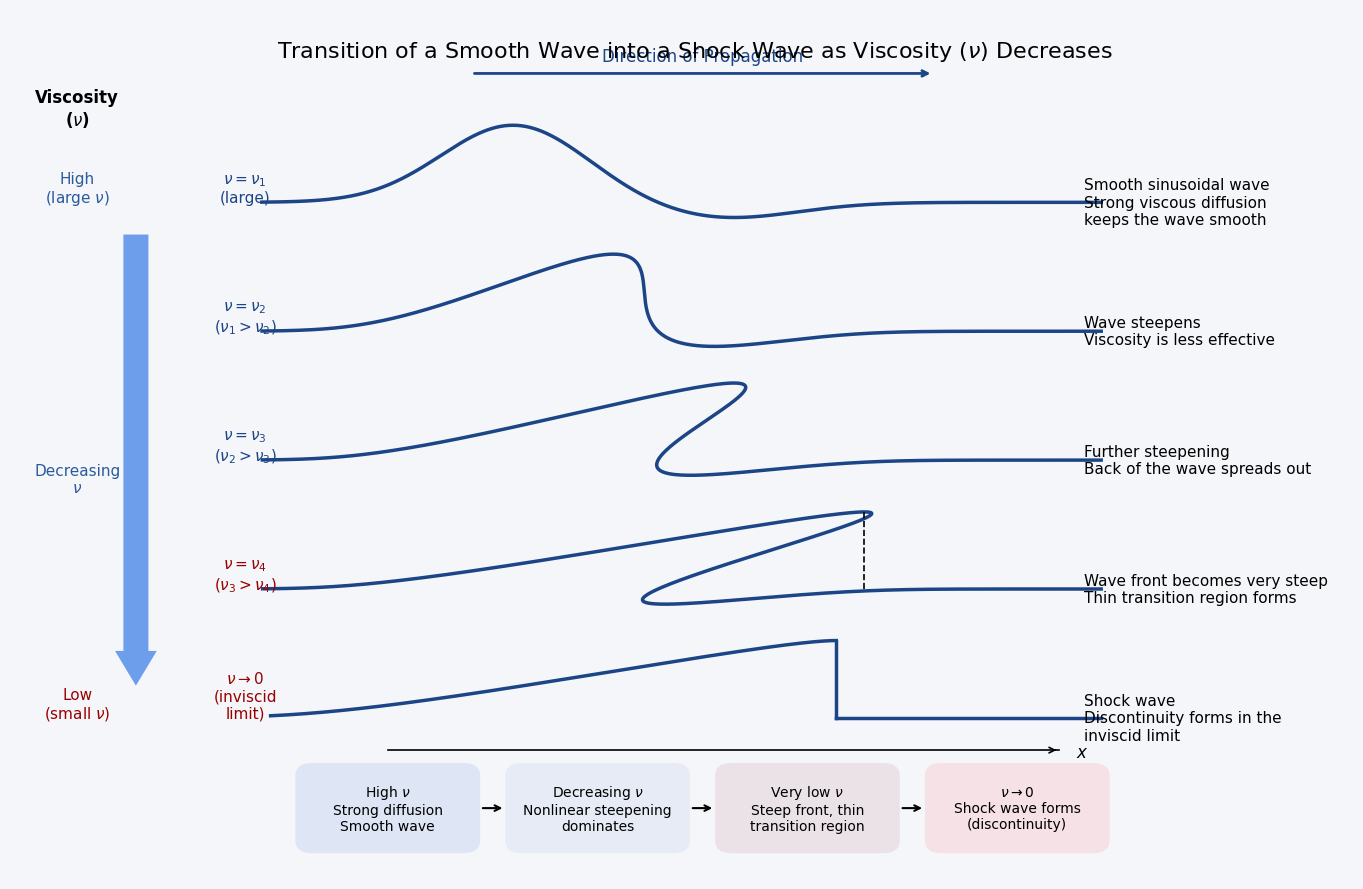

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Figure Setup
fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#F4F6F9')
ax.set_facecolor('#F4F6F9')
ax.axis('off')

# 2. Wave Math Setup
x = np.linspace(0, 10, 800)
# Base shape: Positive pulse with a small trailing dip
y_base = 1.2 * np.exp(-(x - 3)**2 / 1.5) - 0.25 * np.exp(-(x - 5.5)**2 / 1.5)

offsets = [8, 6, 4, 2, 0]
skews = [0, 1.0, 2.2, 3.5] # Increasing skew to simulate decreasing viscosity
wave_color = '#1C4587'

# 3. Plot Waves 1 to 4
for i in range(4):
    x_skew = x + skews[i] * y_base
    ax.plot(x_skew, y_base + offsets[i], color=wave_color, lw=2.5)

    # Wave 4 specific: dashed line for thin transition region
    if i == 3:
        peak_idx = np.argmax(y_base)
        peak_x = x_skew[peak_idx]
        ax.plot([peak_x, peak_x], [offsets[3], offsets[3] + y_base[peak_idx]], 'k--', lw=1.2)

# 4. Plot Wave 5 (Shock Wave - Inviscid Limit)
# For a true shock, the wave drops vertically from the peak
x5 = np.linspace(0, 10, 800)
y5_base = 1.2 * np.exp(-(x5 - 3)**2 / 2.5)
x5_skew = x5 + 3.2 * y5_base
peak_5 = np.argmax(y5_base)
p_x = x5_skew[peak_5]

# Plot up to peak, draw vertical shock, draw flat tail
ax.plot(x5_skew[:peak_5+1], y5_base[:peak_5+1] + offsets[4], color=wave_color, lw=2.5)
ax.plot([p_x, p_x], [offsets[4], offsets[4] + y5_base[peak_5]], color=wave_color, lw=2.5)
ax.plot([p_x, 10], [offsets[4], offsets[4]], color=wave_color, lw=2.5)

# 5. Title & Arrows
plt.figtext(0.5, 0.93, "Transition of a Smooth Wave into a Shock Wave as Viscosity ($\\nu$) Decreases",
            ha='center', fontsize=16, fontname='Arial')

# Top Direction Arrow
ax.annotate('', xy=(8, 10), xytext=(2.5, 10), arrowprops=dict(arrowstyle='->', color=wave_color, lw=2))
ax.text(5.25, 10.2, "Direction of Propagation", color=wave_color, ha='center', fontsize=12, fontname='Arial')

# Bottom X-Axis
ax.plot([1.5, 9.5], [-0.5, -0.5], 'k-', lw=1.2)
ax.annotate('', xy=(9.5, -0.5), xytext=(9.4, -0.5), arrowprops=dict(arrowstyle='->', color='black', lw=1.2))
ax.text(9.7, -0.6, "$x$", fontsize=12, style='italic')

# Left Thick Downward Arrow
ax.annotate('', xy=(-1.5, 0.5), xytext=(-1.5, 7.5),
            arrowprops=dict(width=18, headwidth=30, headlength=25, facecolor='#6D9EEB', edgecolor='none'))

# 6. Text Annotations (Left Side)
left_x1, left_x2 = -2.2, -0.2
ax.text(left_x1, 9.2, "Viscosity\n($\\nu$)", ha='center', fontsize=12, fontweight='bold')
ax.text(left_x1, 8.0, "High\n(large $\\nu$)", ha='center', color='#2B5B9E', fontsize=11)
ax.text(left_x1, 3.5, "Decreasing\n$\\nu$", ha='center', color='#2B5B9E', fontsize=11)
ax.text(left_x1, 0.0, "Low\n(small $\\nu$)", ha='center', color='#990000', fontsize=11)

ax.text(left_x2, 8.0, "$\\nu = \\nu_1$\n(large)", ha='center', color='#1C4587', fontsize=11)
ax.text(left_x2, 6.0, "$\\nu = \\nu_2$\n($\\nu_1 > \\nu_2$)", ha='center', color='#1C4587', fontsize=11)
ax.text(left_x2, 4.0, "$\\nu = \\nu_3$\n($\\nu_2 > \\nu_3$)", ha='center', color='#1C4587', fontsize=11)
ax.text(left_x2, 2.0, "$\\nu = \\nu_4$\n($\\nu_3 > \\nu_4$)", ha='center', color='#990000', fontsize=11)
ax.text(left_x2, 0.0, "$\\nu \\rightarrow 0$\n(inviscid\nlimit)", ha='center', color='#990000', fontsize=11)

# 7. Text Annotations (Right Side)
right_x = 9.8
texts_right = [
    "Smooth sinusoidal wave\nStrong viscous diffusion\nkeeps the wave smooth",
    "Wave steepens\nViscosity is less effective",
    "Further steepening\nBack of the wave spreads out",
    "Wave front becomes very steep\nThin transition region forms",
    "Shock wave\nDiscontinuity forms in the\ninviscid limit"
]
for i in range(5):
    ax.text(right_x, offsets[i], texts_right[i], va='center', fontsize=11)

# 8. Summary Boxes (Bottom)
box_y, box_h = -2.0, 1.2
box_widths, box_x = 2.0, [0.5, 3.0, 5.5, 8.0]
box_colors = ['#DEE6F5', '#E6EBF5', '#EBE2E8', '#F5E1E6']
box_texts = [
    "High $\\nu$\nStrong diffusion\nSmooth wave",
    "Decreasing $\\nu$\nNonlinear steepening\ndominates",
    "Very low $\\nu$\nSteep front, thin\ntransition region",
    "$\\nu \\rightarrow 0$\nShock wave forms\n(discontinuity)"
]

for i in range(4):
    rect = patches.FancyBboxPatch((box_x[i], box_y), box_widths, box_h,
                                  boxstyle="round,pad=0.1,rounding_size=0.2",
                                  facecolor=box_colors[i], edgecolor='none')
    ax.add_patch(rect)
    ax.text(box_x[i] + box_widths/2, box_y + box_h/2, box_texts[i],
            ha='center', va='center', fontsize=10)

    # Add horizontal arrows between boxes
    if i < 3:
        ax.annotate('', xy=(box_x[i+1]-0.1, box_y + box_h/2), xytext=(box_x[i]+box_widths+0.1, box_y + box_h/2),
                    arrowprops=dict(arrowstyle='->', lw=1.5))

plt.xlim(-3, 13)
plt.ylim(-2.5, 11)
plt.tight_layout()
plt.show()

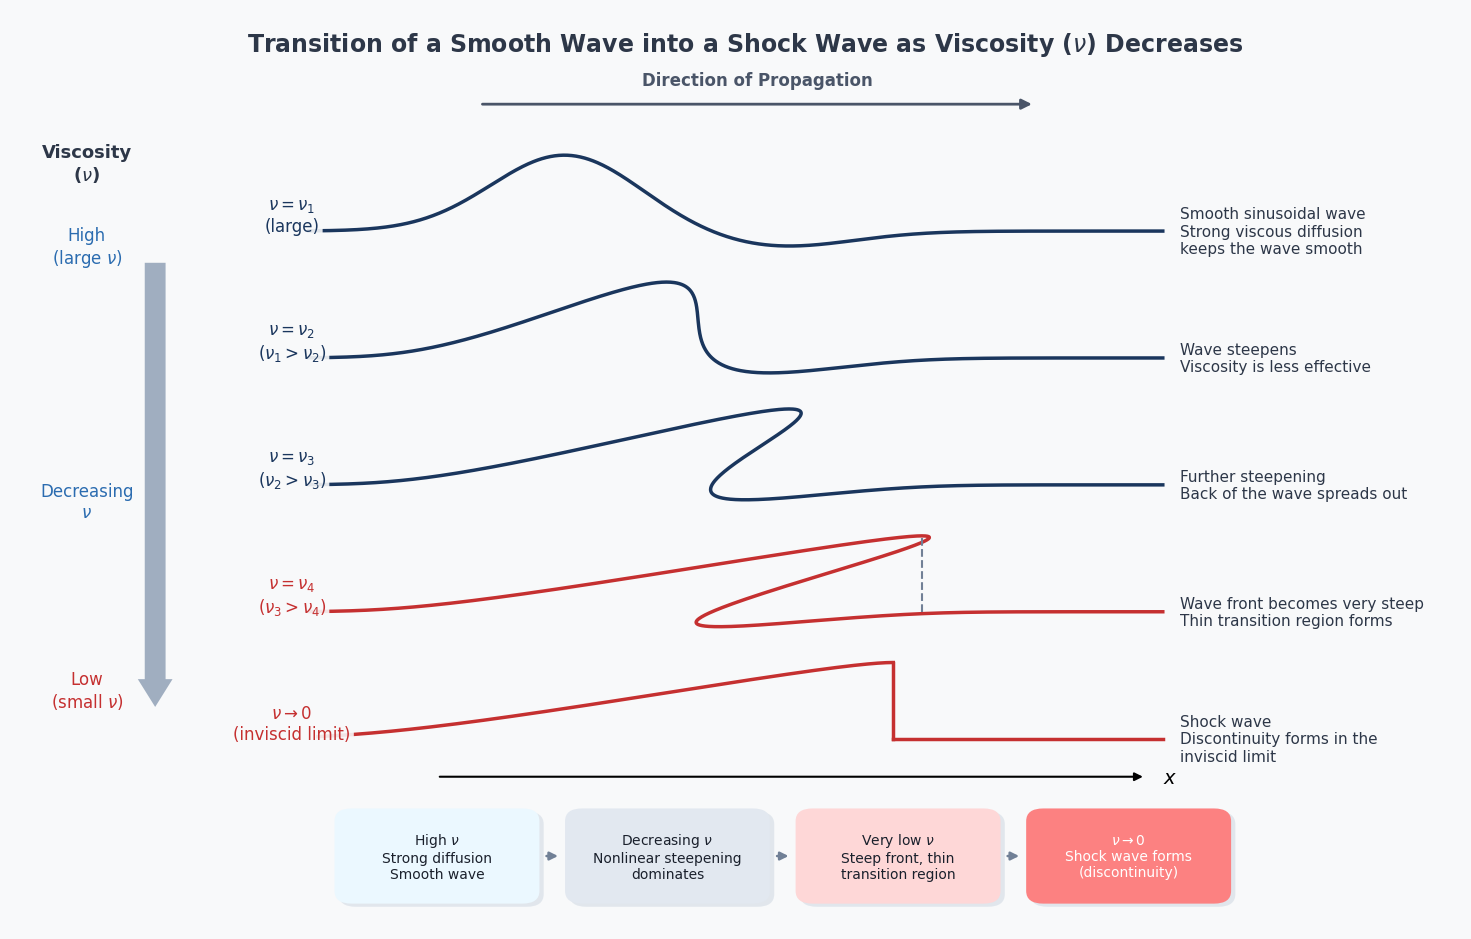

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Premium Figure Setup
fig, ax = plt.subplots(figsize=(15, 9.5))
bg_color = '#F8F9FA'
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# Remove standard spines but keep a clean look
for spine in ax.spines.values():
    spine.set_visible(False)

# Add an aesthetic, subtle grid
ax.grid(True, color='#D1D6DC', linestyle='--', linewidth=0.7, alpha=0.6)
ax.set_axisbelow(True)

# Remove Y-axis ticks but keep X-axis for the 'x' direction
ax.set_yticks([])
ax.set_xticks([])

# 2. Wave Math Setup (Unchanged for accurate physics)
x = np.linspace(0, 10, 800)
y_base = 1.2 * np.exp(-(x - 3)**2 / 1.5) - 0.25 * np.exp(-(x - 5.5)**2 / 1.5)

offsets = [8, 6, 4, 2, 0]
skews = [0, 1.0, 2.2, 3.5]
wave_color = '#1A365D' # Deep aesthetic navy blue
highlight_color = '#C53030' # Elegant deep red for low viscosity

# Anti-superimpose text box properties
text_box = dict(boxstyle="round,pad=0.2", facecolor=bg_color, edgecolor='none', alpha=0.9)

# 3. Plot Waves 1 to 4
for i in range(4):
    x_skew = x + skews[i] * y_base
    color = wave_color if i < 3 else highlight_color
    ax.plot(x_skew, y_base + offsets[i], color=color, lw=2.5)

    # Wave 4 specific: dashed line for thin transition region
    if i == 3:
        peak_idx = np.argmax(y_base)
        peak_x = x_skew[peak_idx]
        ax.plot([peak_x, peak_x], [offsets[3], offsets[3] + y_base[peak_idx]],
                color='#718096', linestyle='--', lw=1.5)

# 4. Plot Wave 5 (Shock Wave - Inviscid Limit)
x5 = np.linspace(0, 10, 800)
y5_base = 1.2 * np.exp(-(x5 - 3)**2 / 2.5)
x5_skew = x5 + 3.2 * y5_base
peak_5 = np.argmax(y5_base)
p_x = x5_skew[peak_5]

ax.plot(x5_skew[:peak_5+1], y5_base[:peak_5+1] + offsets[4], color=highlight_color, lw=2.5)
ax.plot([p_x, p_x], [offsets[4], offsets[4] + y5_base[peak_5]], color=highlight_color, lw=2.5)
ax.plot([p_x, 10], [offsets[4], offsets[4]], color=highlight_color, lw=2.5)

# 5. Title & Arrows
plt.figtext(0.5, 0.94, "Transition of a Smooth Wave into a Shock Wave as Viscosity ($\\nu$) Decreases",
            ha='center', fontsize=17, fontweight='bold', color='#2D3748', fontname='sans-serif')

# Top Direction Arrow
ax.annotate('', xy=(8.5, 10), xytext=(2.0, 10),
            arrowprops=dict(arrowstyle='-|>', color='#4A5568', lw=2, mutation_scale=15))
ax.text(5.25, 10.3, "Direction of Propagation", color='#4A5568', ha='center', fontsize=12, fontweight='bold')

# Bottom X-Axis Arrow
ax.annotate('', xy=(9.8, -0.6), xytext=(1.5, -0.6),
            arrowprops=dict(arrowstyle='-|>', color='black', lw=1.5, mutation_scale=12))
ax.text(10.0, -0.7, "$x$", fontsize=14, style='italic', color='black')

# Left Thick Downward Arrow
ax.annotate('', xy=(-1.8, 0.5), xytext=(-1.8, 7.5),
            arrowprops=dict(width=15, headwidth=25, headlength=20, facecolor='#A0AEC0', edgecolor='none'))

# 6. Text Annotations (Left Side) - Perfectly Aligned
left_x1, left_x2 = -2.6, -0.2
ax.text(left_x1, 8.8, "Viscosity\n($\\nu$)", ha='center', fontsize=13, fontweight='bold', color='#2D3748')
ax.text(left_x1, 7.5, "High\n(large $\\nu$)", ha='center', color='#2B6CB0', fontsize=12)
ax.text(left_x1, 3.5, "Decreasing\n$\\nu$", ha='center', color='#2B6CB0', fontsize=12)
ax.text(left_x1, 0.5, "Low\n(small $\\nu$)", ha='center', color='#C53030', fontsize=12)

ax.text(left_x2, 8.0, "$\\nu = \\nu_1$\n(large)", ha='center', color=wave_color, fontsize=12, bbox=text_box)
ax.text(left_x2, 6.0, "$\\nu = \\nu_2$\n($\\nu_1 > \\nu_2$)", ha='center', color=wave_color, fontsize=12, bbox=text_box)
ax.text(left_x2, 4.0, "$\\nu = \\nu_3$\n($\\nu_2 > \\nu_3$)", ha='center', color=wave_color, fontsize=12, bbox=text_box)
ax.text(left_x2, 2.0, "$\\nu = \\nu_4$\n($\\nu_3 > \\nu_4$)", ha='center', color=highlight_color, fontsize=12, bbox=text_box)
ax.text(left_x2, 0.0, "$\\nu \\rightarrow 0$\n(inviscid limit)", ha='center', color=highlight_color, fontsize=12, bbox=text_box)

# 7. Text Annotations (Right Side) - With Bounding Boxes to avoid Grid overlap
right_x = 10.2
texts_right = [
    "Smooth sinusoidal wave\nStrong viscous diffusion\nkeeps the wave smooth",
    "Wave steepens\nViscosity is less effective",
    "Further steepening\nBack of the wave spreads out",
    "Wave front becomes very steep\nThin transition region forms",
    "Shock wave\nDiscontinuity forms in the\ninviscid limit"
]
for i in range(5):
    ax.text(right_x, offsets[i], texts_right[i], va='center', fontsize=11, color='#2D3748', bbox=text_box)

# 8. Summary Boxes (Bottom) - Elegant styling
box_y, box_h = -2.5, 1.3
box_widths, box_x = 2.2, [0.4, 3.1, 5.8, 8.5]
box_colors = ['#EBF8FF', '#E2E8F0', '#FED7D7', '#FC8181']
box_texts = [
    "High $\\nu$\nStrong diffusion\nSmooth wave",
    "Decreasing $\\nu$\nNonlinear steepening\ndominates",
    "Very low $\\nu$\nSteep front, thin\ntransition region",
    "$\\nu \\rightarrow 0$\nShock wave forms\n(discontinuity)"
]

for i in range(4):
    # Shadow effect for aesthetics
    rect_shadow = patches.FancyBboxPatch((box_x[i]+0.05, box_y-0.05), box_widths, box_h,
                                         boxstyle="round,pad=0.1,rounding_size=0.2",
                                         facecolor='#CBD5E0', edgecolor='none', alpha=0.5)
    ax.add_patch(rect_shadow)

    # Main box
    rect = patches.FancyBboxPatch((box_x[i], box_y), box_widths, box_h,
                                  boxstyle="round,pad=0.1,rounding_size=0.2",
                                  facecolor=box_colors[i], edgecolor='none', zorder=3)
    ax.add_patch(rect)

    text_color = '#1A202C' if i < 3 else 'white'
    ax.text(box_x[i] + box_widths/2, box_y + box_h/2, box_texts[i],
            ha='center', va='center', fontsize=10, color=text_color, fontweight='medium', zorder=4)

    # Add horizontal arrows between boxes
    if i < 3:
        ax.annotate('', xy=(box_x[i+1]-0.15, box_y + box_h/2), xytext=(box_x[i]+box_widths+0.15, box_y + box_h/2),
                    arrowprops=dict(arrowstyle='-|>', lw=1.8, color='#718096', mutation_scale=12))

plt.xlim(-3.5, 13.5)
plt.ylim(-3.0, 11.5)
plt.tight_layout()
plt.show()